# Karman vortex street behind a cylinder (D2Q9 lattice Boltzmann)


In [1]:
import numpy as np
import matplotlib.pyplot as plt


nx, ny, Re, steps = 181, 81, 100.0, 4500

Solver: BGK collision, streaming, bounce-back on the cylinder, momentum-exchange forces

In [2]:
def run_lbm(nx, ny, Re, steps, substeps=4, snap_every=10, n_snap=40):
    U = 0.1                                   # inlet speed (lattice units)
    D = max(4, int(round(ny / 8)))            # cylinder diameter in nodes
    cx, cy = int(round(0.25 * nx)), (ny - 1) / 2
    tau = 0.5 + 3 * U * D / Re
    om = 1 / tau

    c = np.array([[0,0],[1,0],[0,1],[-1,0],[0,-1],[1,1],[-1,1],[-1,-1],[1,-1]])
    w = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36])
    opp = np.array([0, 3, 4, 1, 2, 7, 8, 5, 6])

    jj, ii = np.mgrid[0:ny, 0:nx]
    solid = (ii - cx)**2 + (jj - cy)**2 <= (D / 2)**2
    fluid = ~solid

    def feq(rho, ux, uy):
        out = np.empty((9, *rho.shape))
        usq = ux*ux + uy*uy
        for q in range(9):
            cu = c[q, 0]*ux + c[q, 1]*uy
            out[q] = w[q] * rho * (1 + 3*cu + 4.5*cu*cu - 1.5*usq)
        return out

    def macro(f):
        rho = f.sum(0)
        r = np.where(rho > 1e-30, rho, 1.0)
        ux = np.tensordot(c[:, 0], f, axes=(0, 0)) / r
        uy = np.tensordot(c[:, 1], f, axes=(0, 0)) / r
        ux[solid] = 0; uy[solid] = 0
        return rho, r, ux, uy

    ux0 = np.full((ny, nx), U)
    uy0 = 0.05 * U * np.sin(2*np.pi*jj/ny) * np.exp(-((ii - cx) / (2*D))**2)
    ux0[solid] = 0; uy0[solid] = 0
    f = feq(np.ones((ny, nx)), ux0, uy0)
    f[:, solid] = 0
    f_in = feq(np.ones((ny, 1)), np.full((ny, 1), U), np.zeros((ny, 1)))[:, :, 0]

    hist, snaps, t = [], [], 0
    for step in range(1, steps + 1):
        Fx = Fy = 0.0
        for _ in range(substeps):
            rho, r, ux, uy = macro(f)
            post = f - om * (f - feq(r, ux, uy))
            post[:, solid] = 0
            new = np.zeros_like(f)
            for q in range(9):
                hit = fluid & np.roll(solid, (-c[q, 1], -c[q, 0]), axis=(0, 1))   # link into the cylinder
                s = post[q]
                Fx += 2 * s[hit].sum() * c[q, 0]                                  # momentum exchange
                Fy += 2 * s[hit].sum() * c[q, 1]
                new[q] += np.roll(s * ~hit, (c[q, 1], c[q, 0]), axis=(0, 1))      # streaming
                new[opp[q]][hit] += s[hit]                                        # bounce-back
            f = new
            f[:, :, 0] = f_in                 # inlet
            f[:, :, -1] = f[:, :, -2]         # outlet
            f[:, solid] = 0
            t += 1
        rho, r, ux, uy = macro(f)
        norm = 0.5 * U**2 * D * substeps
        hist.append((t * U / D, Fx / norm, Fy / norm, np.abs(rho[fluid] - 1).max(), np.hypot(ux, uy).max()))
        if step > steps - snap_every * n_snap and step % snap_every == 0:
            snaps.append(vorticity(ux, uy, U, D))
        if hist[-1][4] > 0.45:
            raise RuntimeError("unstable: try a larger ny or a smaller Re")
        if step == 1 or step % max(1, steps // 8) == 0:
            print(f"step {step}: Cd={hist[-1][1]:.4f}  Cl={hist[-1][2]:.4f}  max speed={hist[-1][4]:.4f}")

    hist = np.array(hist)
    fin = dict(rho=rho, ux=ux, uy=uy, vort=vorticity(ux, uy, U, D))
    return dict(hist=hist, snaps=snaps, solid=solid, ii=ii, jj=jj, D=D, cx=cx, cy=cy,
                U=U, substeps=substeps, snap_every=snap_every, **fin)

def vorticity(ux, uy, U, D):
    w = np.zeros_like(ux)
    w[1:-1, 1:-1] = ((uy[1:-1, 2:] - uy[1:-1, :-2]) / 2 - (ux[2:, 1:-1] - ux[:-2, 1:-1]) / 2)
    return w * D / U

def strouhal(cl, dt, D, U):
    s = cl[len(cl) // 2:] - cl[len(cl) // 2:].mean()
    spec = np.abs(np.fft.rfft(s * np.hanning(len(s))))**2
    st = np.fft.rfftfreq(len(s), d=dt) * D / U
    ok = (st >= 0.05) & (st <= 0.35)
    return st[ok][np.argmax(spec[ok])]

Run and summary (Strouhal number, mean drag, lift amplitude, density deviation)

In [3]:
res = run_lbm(nx, ny, Re, steps)
h = res["hist"]
half = len(h) // 2
St = strouhal(h[:, 2], res["substeps"], res["D"], res["U"])
print(f"\nStrouhal number     = {St:.4f}   (reference at Re=100: 0.16 - 0.17)")
print(f"mean drag Cd        = {h[half:, 1].mean():.3f}")
print(f"lift amplitude      = {(h[half:, 2].max() - h[half:, 2].min()) / 2:.3f}")
print(f"max density deviation = {h[half:, 3].max():.4f}   (second half of the run)")

step 1: Cd=19.9854  Cl=0.0343  max speed=0.1157
step 562: Cd=1.5588  Cl=-0.0031  max speed=0.1381
step 1124: Cd=1.6518  Cl=-0.1356  max speed=0.1426
step 1686: Cd=1.7301  Cl=-0.2711  max speed=0.1461
step 2248: Cd=1.8125  Cl=0.2133  max speed=0.1507
step 2810: Cd=1.8178  Cl=0.5026  max speed=0.1512
step 3372: Cd=1.7472  Cl=0.3025  max speed=0.1470
step 3934: Cd=1.8081  Cl=-0.1919  max speed=0.1505
step 4496: Cd=1.8225  Cl=-0.4936  max speed=0.1514

Strouhal number     = 0.1667   (reference at Re=100: 0.16 - 0.17)
mean drag Cd        = 1.783
lift amplitude      = 0.513
max density deviation = 0.0250   (second half of the run)


Lift/drag histories and vorticity field

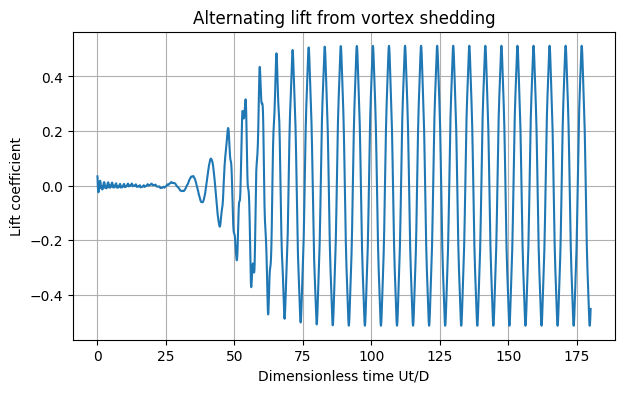

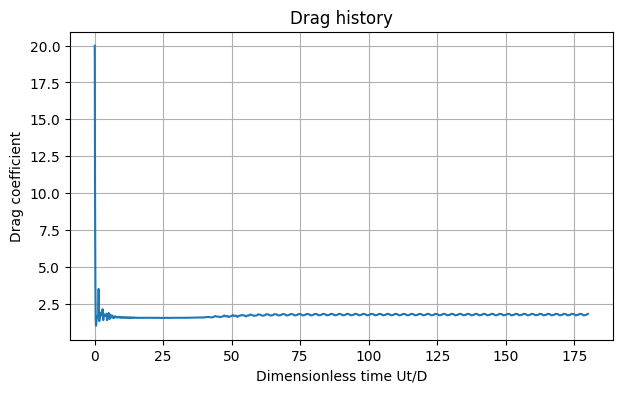

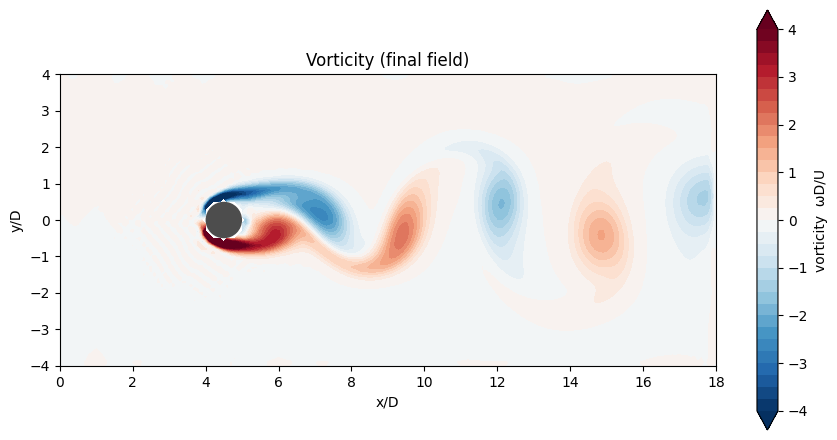

In [4]:
# lift and drag history
for col, name, title in [(2, "Lift coefficient", "Alternating lift from vortex shedding"), (1, "Drag coefficient", "Drag history")]:
    plt.figure(figsize=(7, 4))
    plt.plot(h[:, 0], h[:, col])
    plt.xlabel("Dimensionless time Ut/D"); plt.ylabel(name); plt.title(title); plt.grid(True)
    plt.show()

# final vorticity field
def show_vort(ax, w, title):
    D, cx, cy = res["D"], res["cx"], res["cy"]
    X, Y = (res["ii"] - cx) / D + cx / D, (res["jj"] - cy) / D
    cs = ax.contourf(X, Y, np.ma.masked_where(res["solid"], w), levels=np.linspace(-4, 4, 33), cmap="RdBu_r", extend="both")
    ax.add_patch(plt.Circle((cx / D, 0), 0.5, fc="0.3"))
    ax.set(xlabel="x/D", ylabel="y/D", title=title, aspect="equal")
    return cs

fig, ax = plt.subplots(figsize=(9, 4.5))
plt.colorbar(show_vort(ax, res["vort"], "Vorticity (final field)"), ax=ax, label="vorticity  ωD/U")
plt.tight_layout(); plt.show()

Vorticity sequence over one shedding cycle

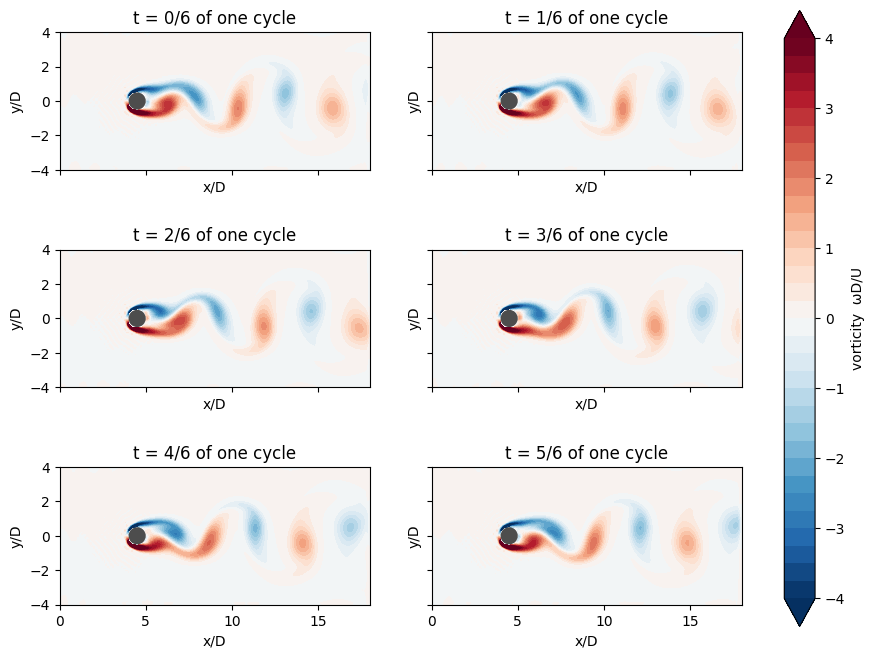

In [5]:
# vorticity over one shedding cycle
period = res["D"] / (St * res["U"]) / res["substeps"] / res["snap_every"]   # snapshots per cycle
picks = [len(res["snaps"]) - 1 - int(round(k * period / 6)) for k in range(6)][::-1]
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey=True)
for a, k, n in zip(axes.ravel(), picks, range(6)):
    cs = show_vort(a, res["snaps"][k], f"t = {n}/6 of one cycle")
fig.colorbar(cs, ax=axes, label="vorticity  ωD/U")
plt.show()

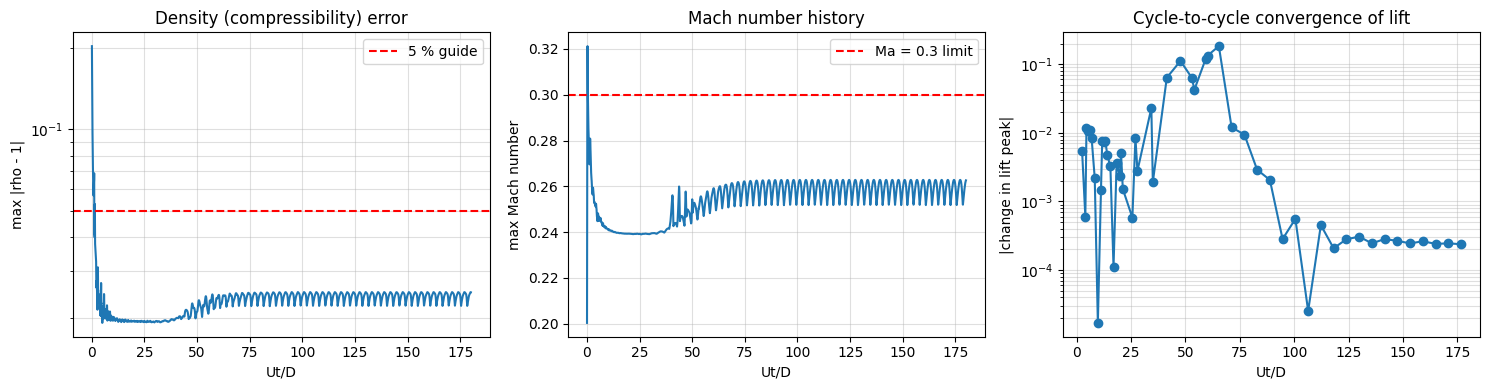

final density error = 0.0250, max Mach: start-up 0.321, after start-up 0.263
last lift-peak change = 2.39e-04  (cycle 50)
mean Cd change, 2nd vs 3rd quarter = 0.0008


In [6]:
# residual / error history (uses h from the run cell)
t, cd, cl, drho, umax = h[:, 0], h[:, 1], h[:, 2], h[:, 3], h[:, 4]
Ma = np.sqrt(3) * umax                       # lattice sound speed = 1/sqrt(3)

# lift peak of each shedding cycle and its change from the previous cycle
pk = np.where((cl[1:-1] > cl[:-2]) & (cl[1:-1] >= cl[2:]) & (cl[1:-1] > 0))[0] + 1
dpk = np.abs(np.diff(cl[pk]))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].semilogy(t, drho)
ax[0].axhline(0.05, color="r", ls="--", label="5 % guide")
ax[0].set(xlabel="Ut/D", ylabel="max |rho - 1|", title="Density (compressibility) error"); ax[0].legend()
ax[1].plot(t, Ma)
ax[1].axhline(0.3, color="r", ls="--", label="Ma = 0.3 limit")
ax[1].set(xlabel="Ut/D", ylabel="max Mach number", title="Mach number history"); ax[1].legend()
ax[2].semilogy(t[pk][1:], dpk, "o-")
ax[2].set(xlabel="Ut/D", ylabel="|change in lift peak|", title="Cycle-to-cycle convergence of lift")
for a in ax: a.grid(alpha=0.4, which="both")
plt.tight_layout(); plt.show()

half = len(t) // 2
print(f"final density error = {drho[-1]:.4f}, max Mach: start-up {Ma.max():.3f}, after start-up {Ma[half:].max():.3f}")
print(f"last lift-peak change = {dpk[-1]:.2e}  (cycle {len(dpk)})")
print(f"mean Cd change, 2nd vs 3rd quarter = {abs(cd[half:3*len(t)//4].mean() - cd[3*len(t)//4:].mean()):.4f}")